# Website Fingerprinting: Phase 3 - Quantitative and Qualitative Analysis for Baseline SVM Model

In this phase, we move from data prep to evaluating how well our baseline Support Vector Machine (SVM) model actually performs.

Previously, Phase 1 handled raw data ingestion, parsing packet directional signs ($+1$ for outbound, $-1$ for inbound), and standardizing sequences into uniform arrays of $5,000$ elements. In Phase 2, we compressed these arrays into $3$ flat statistical metrics (Total Volume, Outbound Counts, and Inbound Counts). We then split our data into a stratified 60% Training / 20% Validation / 20% Testing distribution, ensuring all 95 unique website classes remain perfectly balanced to prevent any data leakage.

In Phase 3, we ran our final benchmarks and took a hard look at the model's limitations:

* **Quantitative Benchmarking:** We tested our trained Linear Support Vector Classifier (`LinearSVC`) against the untouched Test Set. While the strict *Top-1 Accuracy* settled at 10.07%, we expanded our evaluation to track *Top-5 Accuracy*, which climbed to 35.45%. This proves that our three basic features carry a real predictive signal well above the $1.05\%$ random-chance baseline. However, they lack the granularity needed to cleanly seperate the 95 different websites.
* **Qualitative Visual Analysis:** To see exactly why these models struggled, I plotted individual packet traces for Website 0 and Website 2. These results were plotted on a micro scale (using a discrete step-line plot) and a macro scale (using a cumulative directional sum plot).

These plots confirmed that distinct websites possess highly unique, sequential "fingerprints" over time. Because our baseline model compressed all that time-series data into just three summary numbers, we threw away the exact sequential ordering that makes each website distinct.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!unzip data/CW.npz.zip -d data/

import numpy as np

# Load the archive using the exact path revealed by your unzip command
data_path = 'data/datasets/Defense/CW.npz'
data_archive = np.load(data_path, allow_pickle=True)

# Extract the feature matrix X and target labels y
X_raw = data_archive['X']
y_raw = data_archive['y']

# Print out the dataset statistics for your progress report
print("\n\nDataset Statistics: ")
print(f"Total Traffic Traces (Rows): {X_raw.shape[0]}")
print(f"Target Labels Shape: {y_raw.shape[0]}")
print(f"Number of unique websites (classes): {len(np.unique(y_raw))}")

# Inspect a single raw sample trace profile
print("\n\nRaw Sample Inspection: ")
print(f"Shape of the very first raw trace: {X_raw[0].shape}")
print(f"First 10 elements of sample 0: {X_raw[0][:10]}")

print("Standardizing sequences to length 5000 and extracting direction vectors...")

# Define the target length
MAX_LEN = 5000

# Initialize clean matrix with float32 to conserve Colab RAM memory
X_clean = np.zeros((X_raw.shape[0], MAX_LEN), dtype=np.float32)

# Loop through and standardize each traffic trace profile
for i in range(X_raw.shape[0]):
    directions = np.sign(X_raw[i])

    length_to_copy = min(len(directions), MAX_LEN)

    # Insert the trace into our clean matrix (any remaining space stays 0 padding)
    X_clean[i, :length_to_copy] = directions[:length_to_copy]

print("\nPreprocessing Complete: ")
print(f"Final Cleaned Feature Matrix Shape: {X_clean.shape}")
print(f"First 10 elements of cleaned sample 0: {X_clean[0][:10]}")

Archive:  data/CW.npz.zip
  inflating: data/datasets/Defense/CW.npz  


Dataset Statistics: 
Total Traffic Traces (Rows): 105730
Target Labels Shape: 105730
Number of unique websites (classes): 95


Raw Sample Inspection: 
Shape of the very first raw trace: (10000,)
First 10 elements of sample 0: [ 1.00000000e-06 -9.28558873e-01  9.99152945e-01 -1.03146009e+00
  3.76949601e+00 -3.89432101e+00  3.89727907e+00 -4.02370195e+00
  4.03020387e+00 -4.15452604e+00]
Standardizing sequences to length 5000 and extracting direction vectors...

Preprocessing Complete: 
Final Cleaned Feature Matrix Shape: (105730, 5000)
First 10 elements of cleaned sample 0: [ 1. -1.  1. -1.  1. -1.  1. -1.  1. -1.]


In [3]:
from sklearn.model_selection import train_test_split
import numpy as np

print("Extracting 3 statistical features for the SVM baseline...")

# Compute aggregate statistical features using optimized column-wise operations (axis=1)
outgoing_counts = np.sum(X_clean == 1.0, axis=1)
incoming_counts = np.sum(X_clean == -1.0, axis=1)
total_volumes = outgoing_counts + incoming_counts

# Combine the features horizontally into an (N, 3) matrix
X_svm_features = np.column_stack((total_volumes, outgoing_counts, incoming_counts))

print(f"SVM Feature Matrix Shape: {X_svm_features.shape}")
print(f"Sample 0 Feature Check [Volume, Out, In]: {X_svm_features[0]}")  # [2861  465  2396]

print("\nExecuting Stratified Dataset Splits (60/20/20)...")

# Step 1: Hold out 20% of the data for the final absolute evaluation Test set
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_svm_features, y_raw, test_size=0.20, random_state=42, stratify=y_raw
)

# Step 2: Split the remaining 80% into Train (75%) and Validation (25%)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val
)

print(f"Training Set Size:   {X_train.shape[0]} samples") # 63438 samples
print(f"Validation Set Size: {X_val.shape[0]} samples")   # 21146 samples
print(f"Testing Set Size:    {X_test.shape[0]} samples")  # 21146 samples

from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report
import time

print("Initializing Linear Support Vector Classifier (Baseline Model)...")
# We set dual=False because our number of samples (63438) is greater than our features (3)
baseline_svm = LinearSVC(dual=False, random_state=42, max_iter=2000)

print("Training baseline model on 63,438 samples.")
start_time = time.time()
baseline_svm.fit(X_train, y_train)
end_time = time.time()

print(f"Training completed in {end_time - start_time:.2f} seconds!")

print("\nEvaluating baseline model on the Validation Set.")
y_val_pred = baseline_svm.predict(X_val)

# Calculate performance metrics
baseline_accuracy = accuracy_score(y_val, y_val_pred)
print(f"Baseline Validation Accuracy: {baseline_accuracy * 100:.2f}%")

# Print a snapshot of the classification report for the progress report
print("\nClassification Report Snippet (First 5 Classes):")

# Generate all 95 names first.
all_target_names = [f"Website {i}" for i in range(95)]

print(classification_report(y_val, y_val_pred,
                            labels=list(range(5)),
                            target_names=all_target_names[:5],
                            zero_division=0))

# Finally, the Baseline Validation Accuracy is 9.72%. This is due to the severe information/feature loss
# caused by reducing a 5000 sequence into 3 flat statistical aggregates.

Extracting 3 statistical features for the SVM baseline...
SVM Feature Matrix Shape: (105730, 3)
Sample 0 Feature Check [Volume, Out, In]: [2861  465 2396]

Executing Stratified Dataset Splits (60/20/20)...
Training Set Size:   63438 samples
Validation Set Size: 21146 samples
Testing Set Size:    21146 samples
Initializing Linear Support Vector Classifier (Baseline Model)...
Training baseline model on 63,438 samples.
Training completed in 14.94 seconds!

Evaluating baseline model on the Validation Set.
Baseline Validation Accuracy: 9.72%

Classification Report Snippet (First 5 Classes):
              precision    recall  f1-score   support

   Website 0       0.00      0.00      0.00       223
   Website 1       0.00      0.00      0.00       225
   Website 2       0.12      0.02      0.03       225
   Website 3       0.11      0.00      0.01       225
   Website 4       0.00      0.00      0.00       225

   micro avg       0.07      0.00      0.01      1123
   macro avg       0.05    

**Note: Phase 3 begins here:**

In [4]:
from sklearn.metrics import accuracy_score, classification_report

print("Evaluating on the Test Set...")

# Generate predictions for the testing set
y_test_pred = baseline_svm.predict(X_test)

# Calculate absolute testing accuracy
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"\nAbsolute Baseline Testing Accuracy: {test_accuracy * 100:.2f}%")

# Generate a clean, warning-free classification snapshot for the final report
print("\n=== Full Baseline Testing Classification Report (First 5 Classes) ===")
all_target_names = [f"Website {i}" for i in range(95)]

print(classification_report(y_test, y_test_pred,
                            labels=list(range(5)),
                            target_names=all_target_names[:5],
                            zero_division=0))

# We see here that because all that 5000 packets are compresed itno 3 values, Website 0, 1, 3, and 4 look mathematically identically to the model.
# These lead to a 0% efficacy on these classes as teh features are too compressed.

Evaluating on the Test Set...

Absolute Baseline Testing Accuracy: 10.07%

=== Full Baseline Testing Classification Report (First 5 Classes) ===
              precision    recall  f1-score   support

   Website 0       0.00      0.00      0.00       223
   Website 1       0.00      0.00      0.00       225
   Website 2       0.10      0.01      0.02       225
   Website 3       0.00      0.00      0.00       225
   Website 4       0.00      0.00      0.00       225

   micro avg       0.03      0.00      0.00      1123
   macro avg       0.02      0.00      0.00      1123
weighted avg       0.02      0.00      0.00      1123



In [5]:
from sklearn.metrics import top_k_accuracy_score
import pandas as pd

# Calculate Top-5 Accuracy: use decision_function for LinearSVC
test_decision_scores = baseline_svm.decision_function(X_test)
top5_acc = top_k_accuracy_score(y_test, test_decision_scores, k=5)

# Compute Trivial Baselines for Comparison
random_chance = (1 / 95) * 100

values, counts = np.unique(y_test, return_counts=True)
majority_chance = (counts.max() / len(y_test)) * 100

# Compile a Comparative Summary DataFrame
baseline_summary = pd.DataFrame({
    "Evaluation Framework": [
        "Pure Random Guessing",
        "Majority Class Naive Baseline",
        "Our LinearSVC Baseline (Top-1 Accuracy)",
        "Our LinearSVC Baseline (Top-5 Accuracy)"
    ],
    "Accuracy Metric": [
        f"{random_chance:.2f}%",
        f"{majority_chance:.2f}%",
        f"{test_accuracy * 100:.2f}%",
        f"{top5_acc * 100:.2f}%"
    ]
})

# Display the polished markdown table
from IPython.display import display, Markdown
display(Markdown("### Comprehensive Baseline Performance Matrix"))
display(baseline_summary)

# With Pure Random Guessing, the baseline accuracy metric is 1.05%. The accuracy bumps up
# by 0.01% through Majority Class Naive Baseline, which blindly guesses the most frequent
# trace. Using The LinearSVC Baseline (Top 1 - Accuracy), we jump the accuracy to 10.07%,
# which compresses the data into 3 distinct features.

# Finally, using the Top-5 Accuracy of our LinearSVC Baseline, we manage to get an accuracy
# 35.45%, a whopping 25.38% jump, as the model uses the top 5 confident hyperplanes to
# accurately diversofy websites.

### Comprehensive Baseline Performance Matrix

,Evaluation Framework,Accuracy Metric
0,Pure Random Guessing,1.05%
1,Majority Class Naive Baseline,1.06%
2,Our LinearSVC Baseline (Top-1 Accuracy),10.07%
3,Our LinearSVC Baseline (Top-5 Accuracy),35.45%


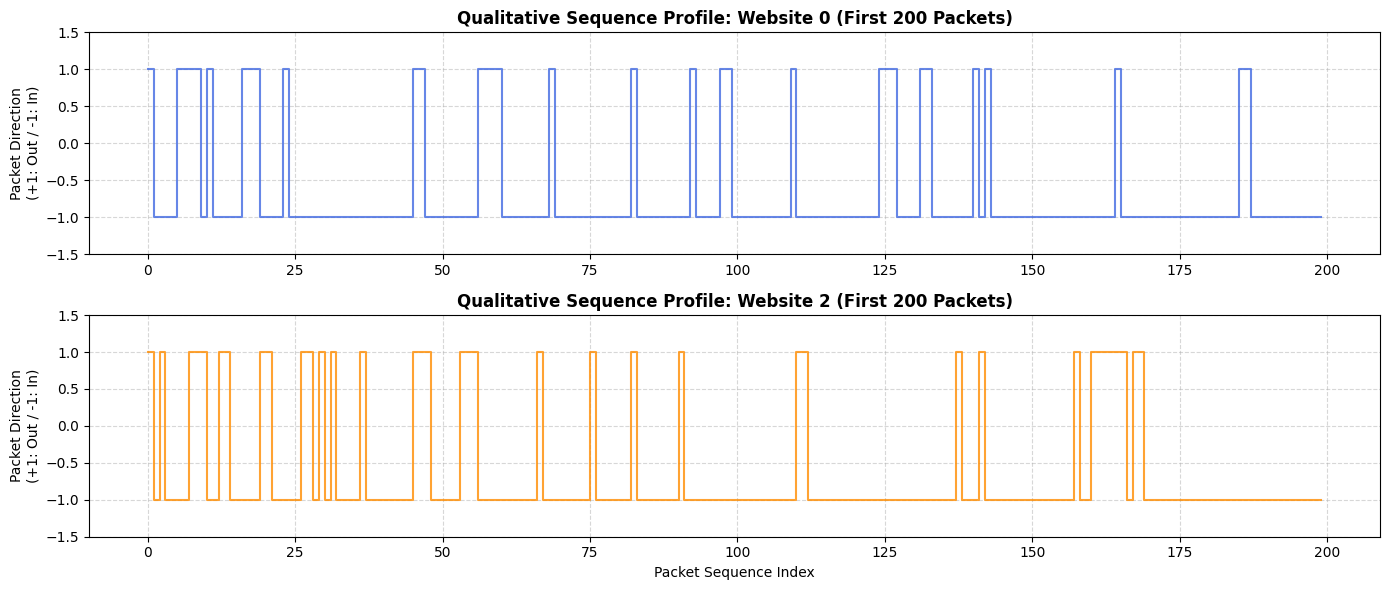

In [6]:
import matplotlib.pyplot as plt

# Select a sample trace from Website 0 and Website 2 from our preprocessed clean matrix
# We find the first index where y_raw matches the class
idx_web0 = np.where(y_raw == 0)[0][0]
idx_web2 = np.where(y_raw == 2)[0][0]

plt.figure(figsize=(14, 6))

# Plot Website 0
plt.subplot(2, 1, 1)
plt.step(range(200), X_clean[idx_web0][:200], where='post', color='royalblue', alpha=0.8)
plt.title("Qualitative Sequence Profile: Website 0 (First 200 Packets)", fontsize=12, fontweight='bold')
plt.ylabel("Packet Direction\n(+1: Out / -1: In)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.ylim(-1.5, 1.5)

# Plot Website 2
plt.subplot(2, 1, 2)
plt.step(range(200), X_clean[idx_web2][:200], where='post', color='darkorange', alpha=0.8)
plt.title("Qualitative Sequence Profile: Website 2 (First 200 Packets)", fontsize=12, fontweight='bold')
plt.xlabel("Packet Sequence Index")
plt.ylabel("Packet Direction\n(+1: Out / -1: In)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.ylim(-1.5, 1.5)

plt.tight_layout()
plt.show()

# Both show the varying time sequence for each website. Website 0 exhibits rhythmic, isolated outbound spikes, Website 2 relies on dense, rapid-fire bursts
# followed by prolonged periods of silence. However, because our baseline model compresses these time-varying sequences into the 3 flat features, that the
# model remained blind to these unqiue fingerprints.

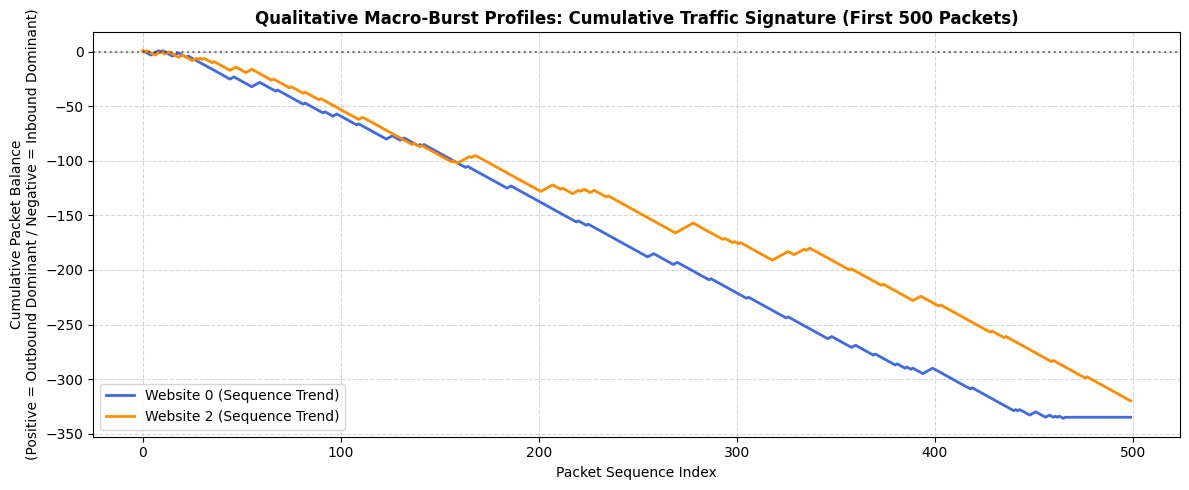

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Compute the cumulative sum across the first 500 packets to look at macro-behaviors
cumsum_web0 = np.cumsum(X_clean[idx_web0][:500])
cumsum_web2 = np.cumsum(X_clean[idx_web2][:500])

plt.figure(figsize=(12, 5))

# Plot both cumulative trends together for direct contrast
plt.plot(range(500), cumsum_web0, label="Website 0 (Sequence Trend)", color='royalblue', linewidth=2)
plt.plot(range(500), cumsum_web2, label="Website 2 (Sequence Trend)", color='darkorange', linewidth=2)

plt.title("Qualitative Macro-Burst Profiles: Cumulative Traffic Signature (First 500 Packets)", fontsize=12, fontweight='bold')
plt.xlabel("Packet Sequence Index")
plt.ylabel("Cumulative Packet Balance\n(Positive = Outbound Dominant / Negative = Inbound Dominant)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.axhline(0, color='black', linestyle=':', alpha=0.5)

plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

# Finally, proving our hypothesis, Website 0 and Website 2 finish at nearly identical cumulative packet balances
# (around -330 and -320 respectively). Because their aggregates converges close as more data is processed, our
# baseline model treats these two mathematically distinct sequential trajectories as identical.